# AI-Powered EDA & Statistical Storytelling — Mini Project

## Business Case
You are a Data Analyst for an Indian e-commerce company.

Management wants to understand:
- What is driving order value?
- Which categories, cities and customer types perform best?
- Does delivery experience affect customer satisfaction?
- Which marketing channels appear stronger?
- Are there unusual orders or data-quality problems?
- Can the analysis be converted into a short, decision-ready business story?

### Dataset
`AI_Powered_Ecommerce_EDA_Project_Dataset.csv`

The dataset contains **1,201 rows**, including one intentional duplicate, and several missing values/outliers for data-cleaning practice.

### Project Outcome
By the end, students should produce:
1. Data-quality assessment
2. Summary statistics
3. Business-focused visualizations
4. Correlation analysis
5. Anomaly detection
6. AI-assisted interpretation
7. A structured statistical/data story
8. 5 actionable business recommendations

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp

# Part 1 — Understand the Data

### Student Tasks
1. How many rows and columns are present?
2. What is the data type of each column?
3. Which columns contain missing values?
4. Are there duplicate rows?
5. Which columns are numeric and which are categorical?

In [3]:
fp = r"C:\MANISH\EXAM\DATA ANALYTICS\POWER BI\PYTH0N\Project Files\Project Files\Ecommerce_EDA_Project_Dataset.csv"
df = pd.read_csv(fp)

In [4]:
df.shape


(1201, 19)

In [5]:
duplicates = df.duplicated().sum()
print("No. of duplicate rows:",duplicates)

No. of duplicate rows: 1


In [6]:
df.dtypes

Order_ID                  object
Order_Date                object
City                      object
Category                  object
Customer_Type             object
Payment_Method            object
Marketing_Channel         object
Quantity                   int64
Unit_Price                 int64
Discount_Pct             float64
Shipping_Cost              int64
Delivery_Days              int64
Order_Amount             float64
Rating                   float64
Customer_Satisfaction    float64
Return_Flag               object
Status                    object
Unnamed: 17              float64
Unnamed: 18              float64
dtype: object

In [7]:
df.shape

(1201, 19)

In [8]:
number = df.select_dtypes(include="number").columns
category = df.select_dtypes(include="object").columns
print("total no.:", number)
print("Total category:", category)

total no.: Index(['Quantity', 'Unit_Price', 'Discount_Pct', 'Shipping_Cost',
       'Delivery_Days', 'Order_Amount', 'Rating', 'Customer_Satisfaction',
       'Unnamed: 17', 'Unnamed: 18'],
      dtype='object')
Total category: Index(['Order_ID', 'Order_Date', 'City', 'Category', 'Customer_Type',
       'Payment_Method', 'Marketing_Channel', 'Return_Flag', 'Status'],
      dtype='object')


In [57]:
def TheLibraryFineSystem(num):

    if num % 3 == 0 and num % 5 == 0:
        return "Membership Cancelled"

    elif num % 3 == 0:
        return "Return Book"

    elif num % 5 == 0:
        return "Pay fine"

    else:
        return num


num = int(input("Enter a number: "))

print(TheLibraryFineSystem(num))

Enter a number:  5


Pay fine


### Business interpretation

A first EDA check should answer:

> **Can I trust this dataset enough to start analyzing it?**

Here we intentionally have missing values and a duplicate so students can practice identifying data-quality issues before drawing business conclusions.

# Part 2 — Data Cleaning

### Student Tasks
- Remove duplicate rows.
- Fill missing `Rating` and `Customer_Satisfaction` using a suitable central value.
- Fill missing categorical values with `"Unknown"`.
- Check whether `Delivery_Days` contains suspicious values.
- Recheck the dataset after cleaning.

**Think before coding:** Why is median a reasonable choice for rating/satisfaction?

In [9]:
df = df.drop_duplicates()
df.head(1)

,Order_ID,Order_Date,City,Category,Customer_Type,Payment_Method,Marketing_Channel,Quantity,Unit_Price,Discount_Pct,Shipping_Cost,Delivery_Days,Order_Amount,Rating,Customer_Satisfaction,Return_Flag,Status,Unnamed: 17,Unnamed: 18
0,ORD100001,17-01-2026,Delhi,Fashion,Returning,UPI,Paid Search,3,1640,11.3,68,25,4653.64,3.0,4.2,No,Delivered,NaN,4988.0


In [10]:
# Fill missing Rating and Customer_Satisfaction using a suitable central value.

df["Rating"] = df["Rating"].fillna(df["Rating"].median())
df["Customer_Satisfaction"] = df["Customer_Satisfaction"].fillna(df["Customer_Satisfaction"].median())

In [11]:
# Check whether Delivery_Days contains suspicious values.
df["Delivery_Days"].describe()

count    1200.000000
mean        3.255000
std         1.392812
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        25.000000
Name: Delivery_Days, dtype: float64

In [12]:
print("Delivery Days contains suspicious values = 25")

Delivery Days contains suspicious values = 25


In [13]:
# Fill missing categorical values with "Unknown"

df.isnull().sum()

df["Payment_Method"] = df["Payment_Method"].fillna("Unknown")
df["Marketing_Channel"] = df["Marketing_Channel"].fillna("Unknown")

### Cleaning decision

The `Delivery_Days = 25` observation is suspicious compared with the normal range in this dataset.

For a classroom project, **do not automatically delete it**. Flag it first and explain why it may be an anomaly. In a real project, the analyst would confirm it with the operations/business team.

# Part 3 — Summary Statistics

### Student Tasks
Calculate:
- Mean, median and standard deviation of `Order_Amount`
- Minimum and maximum order amount
- Mean delivery days
- Mean rating and satisfaction
- Total sales
- Number of orders

In [14]:
# Mean, median and standard deviation of Order_Amount

df["Order_Amount"].agg(["mean", "median", "std"])

mean      8896.048825
median    5486.250000
std       9738.428920
Name: Order_Amount, dtype: float64

In [15]:
# Minimum and maximum order amount

Minimum = df["Order_Amount"].min()
Maximum = df["Order_Amount"].max()
print("Minimum order amount:",Minimum)
print("Maximum order amount:",Maximum)

Minimum order amount: 394.17
Maximum order amount: 102663.05


In [16]:
# Mean delivery days

Avg_Delivery_Days = df["Delivery_Days"].mean()
print("Average Delivery Days :",Avg_Delivery_Days)

Average Delivery Days : 3.255


In [17]:
# Mean rating and satisfaction

df[["Rating", "Customer_Satisfaction"]].mean()

Rating                   4.137167
Customer_Satisfaction    4.029417
dtype: float64

In [18]:
# Total sales

Total_Sales = df["Order_Amount"].sum()
print("Total sales:",Total_Sales)

Total sales: 10675258.59


In [19]:
df.head(1)

,Order_ID,Order_Date,City,Category,Customer_Type,Payment_Method,Marketing_Channel,Quantity,Unit_Price,Discount_Pct,Shipping_Cost,Delivery_Days,Order_Amount,Rating,Customer_Satisfaction,Return_Flag,Status,Unnamed: 17,Unnamed: 18
0,ORD100001,17-01-2026,Delhi,Fashion,Returning,UPI,Paid Search,3,1640,11.3,68,25,4653.64,3.0,4.2,No,Delivered,NaN,4988.0


In [20]:
# Number of orders

In [21]:
Total_Orders = df["Order_ID"].count()
print("Total orders:",Total_Orders)

Total orders: 1200


### AI-assisted EDA prompt

After generating the summary table, students can give the key statistics to an AI assistant with a prompt such as:

> **"Act as a senior e-commerce data analyst. Interpret these summary statistics for a business audience. Identify 3 important patterns, 2 risks, and 2 questions that management should investigate next. Do not invent facts that are not present in the data."**

#action br management, what should they do, some numberical values 

**AI rule:** The analyst remains responsible for checking whether every AI-generated claim is supported by the actual data.

# Part 4 — Category and Customer Analysis

### Questions
1. Which category has the highest total sales?
2. Which category has the highest average order value?
3. Which customer type spends the most on average?
4. Which city generates the most sales?
5. Which marketing channel generates the most sales?

In [22]:
# Which category has the highest total sales?

df.groupby("Category")["Order_Amount"].sum().idxmax()


'Electronics'

In [23]:
# Which category has the highest average order value?

df.groupby("Category")["Order_Amount"].mean().idxmax()


'Electronics'

In [24]:
# Which customer type spends the most on average?
df.head(1)
df.groupby("Customer_Type")["Order_Amount"].mean().idxmax()


'VIP'

In [25]:
# Which city generates the most sales?

df.groupby("City")["Order_Amount"].sum().idxmax()

'Pune'

In [26]:
# Which marketing channel generates the most sales?
df.head(1)
df.groupby("Marketing_Channel")["Order_Amount"].sum().idxmax()

'Organic'

# Part 5 — Visual Storytelling

Create at least these 5 visuals:

1. Sales by category
2. Average order value by customer type
3. Sales by city
4. Distribution of order amount
5. Delivery days vs customer satisfaction

### Visualization principle

Do not create a chart just because you can.

For every chart, answer:

> **What business question does this chart help answer?**

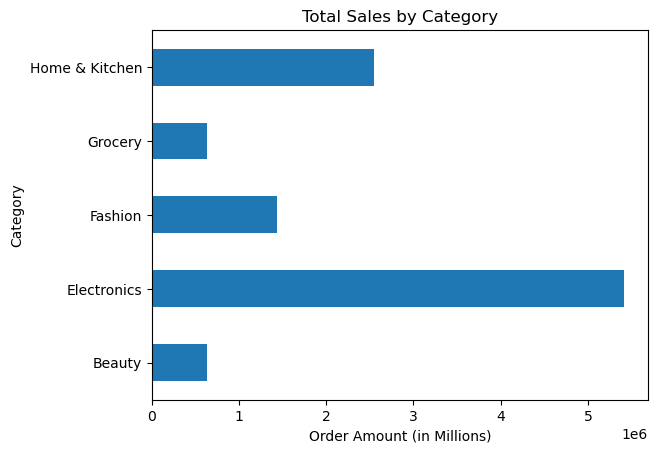

In [27]:
Total_sales = df.groupby("Category")["Order_Amount"].sum()

Total_sales.plot(kind="barh")

plt.xlabel("Order Amount (in Millions)")
plt.ylabel("Category")
plt.title("Total Sales by Category")

plt.show()

(array([0, 1, 2]),
 [Text(0, 0, 'New'), Text(1, 0, 'Returning'), Text(2, 0, 'VIP')])

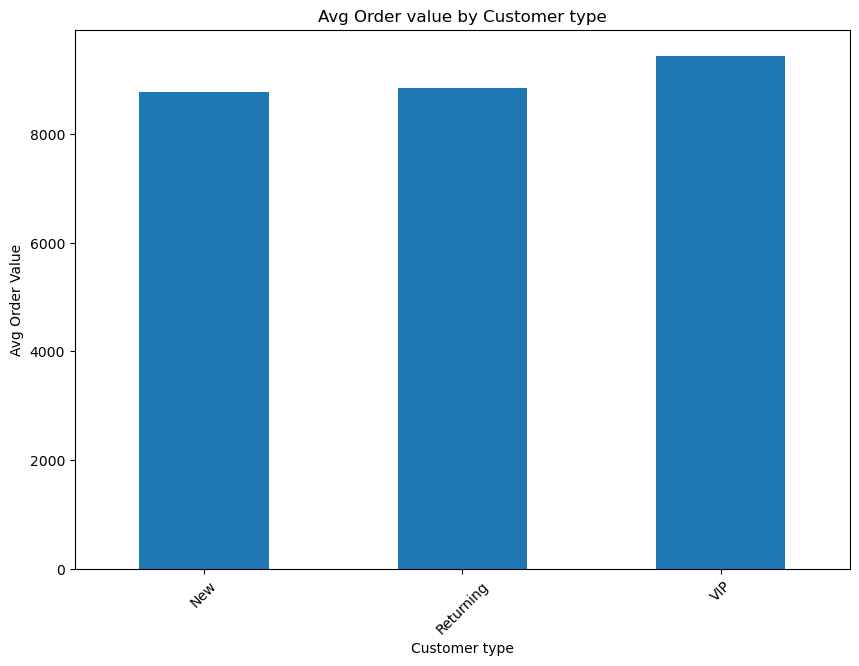

In [28]:
# 2. Average order value by customer type

Average_order=df.groupby("Customer_Type")["Order_Amount"].mean()
Average_order.plot(kind= "bar",figsize=(10,7))

plt.title("Avg Order value by Customer type")
plt.xlabel("Customer type")
plt.ylabel("Avg Order Value")
plt.xticks(rotation=45)


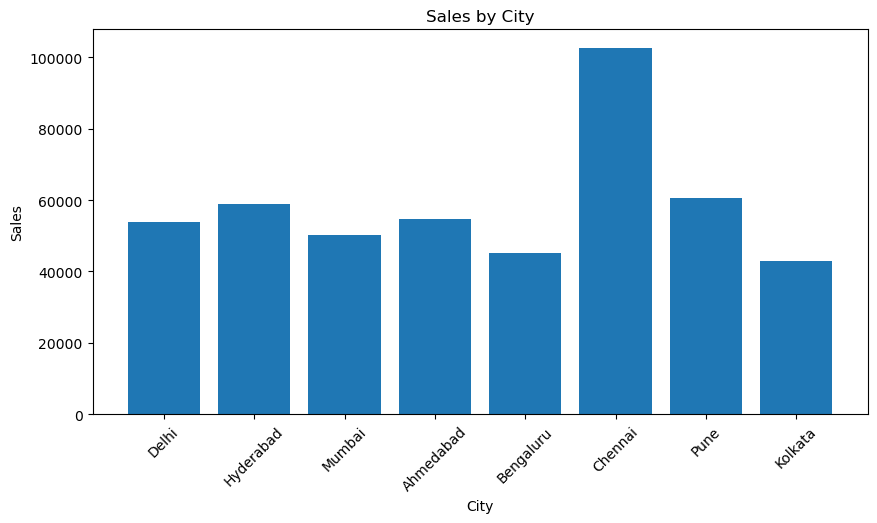

In [29]:
# 3. Sales by city

plt.figure(figsize=(10, 5))

plt.bar(
    df["City"],
    df["Order_Amount"]
)

plt.title("Sales by City")
plt.xlabel("City")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()


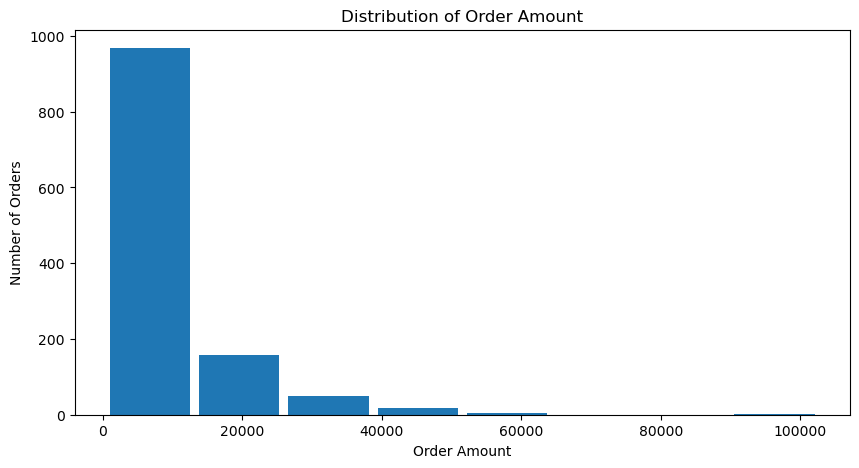

In [30]:
# 4. Distribution of order amount
plt.figure(figsize=(10,5))

plt.hist(
    df["Order_Amount"],
    rwidth=0.9,
    bins=8
)

plt.title("Distribution of Order Amount")
plt.xlabel("Order Amount")
plt.ylabel("Number of Orders")

plt.show()

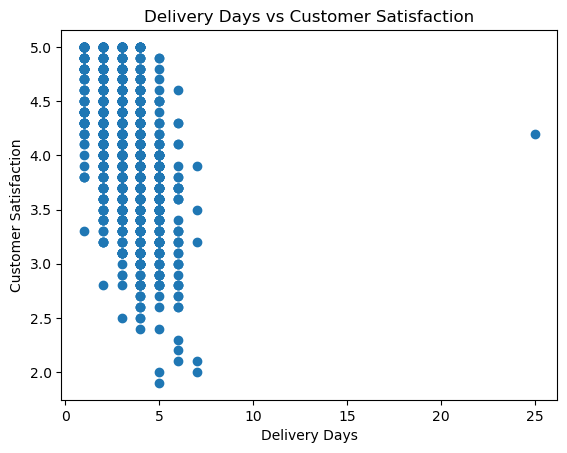

In [31]:
# 5. Delivery days vs customer satisfaction

plt.scatter(
    df["Delivery_Days"],
    df["Customer_Satisfaction"]
)

plt.title("Delivery Days vs Customer Satisfaction")
plt.xlabel("Delivery Days")
plt.ylabel("Customer Satisfaction")

plt.show()

# More Delivery Days lower customer satisfaction

# Part 6 — Correlation Analysis

### Student Questions
1. Which numeric variables have the strongest positive relationship with `Order_Amount`?
2. Is delivery speed related to satisfaction?
3. Is rating related to satisfaction?
4. Does correlation prove causation?

Remember:

> **Correlation indicates association; it does not by itself prove causation.**

In [32]:
df.head(1)

,Order_ID,Order_Date,City,Category,Customer_Type,Payment_Method,Marketing_Channel,Quantity,Unit_Price,Discount_Pct,Shipping_Cost,Delivery_Days,Order_Amount,Rating,Customer_Satisfaction,Return_Flag,Status,Unnamed: 17,Unnamed: 18
0,ORD100001,17-01-2026,Delhi,Fashion,Returning,UPI,Paid Search,3,1640,11.3,68,25,4653.64,3.0,4.2,No,Delivered,NaN,4988.0


In [33]:
# Sort correlations with Order_Amount
df.corr(numeric_only=True)["Order_Amount"].sort_values()

Discount_Pct            -0.072273
Customer_Satisfaction   -0.022294
Delivery_Days            0.001080
Shipping_Cost            0.004922
Rating                   0.010228
Quantity                 0.436258
Unnamed: 18              0.536721
Unit_Price               0.736676
Order_Amount             1.000000
Unnamed: 17                   NaN
Name: Order_Amount, dtype: float64

In [34]:
# Pearson correlation between delivery days and satisfaction

Corr = df["Delivery_Days"].corr(
   df["Customer_Satisfaction"])
round(Corr, 2)

np.float64(-0.47)

### Statistical interpretation template

If the p-value is below 0.05:

> There is statistical evidence of an association between delivery days and customer satisfaction in this dataset.

If the correlation is negative:

> The negative correlation suggests that longer delivery times tend to be associated with lower satisfaction.

Avoid saying:

> "Longer delivery causes dissatisfaction."

That causal statement requires a stronger research design.

# Part 7 — Anomaly Detection using IQR

### Business Question

Which orders look unusually high compared with the rest of the dataset?

Use the **IQR method**.

Formula:

- Q1 = 25th percentile
- Q3 = 75th percentile
- IQR = Q3 − Q1
- Lower bound = Q1 − 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR

In [37]:
df.head(1)

,Order_ID,Order_Date,City,Category,Customer_Type,Payment_Method,Marketing_Channel,Quantity,Unit_Price,Discount_Pct,Shipping_Cost,Delivery_Days,Order_Amount,Rating,Customer_Satisfaction,Return_Flag,Status,Unnamed: 17,Unnamed: 18
0,ORD100001,17-01-2026,Delhi,Fashion,Returning,UPI,Paid Search,3,1640,11.3,68,25,4653.64,3.0,4.2,No,Delivered,NaN,4988.0


In [49]:
Q1 = round(df["Order_Amount"].quantile(0.25),2)
Q3 = round(df["Order_Amount"].quantile(0.75),2)
IQR = Q3 - Q1
Upper_bound = Q3 + 1.5* IQR
Lower_bound = Q1 - 1.5* IQR


In [55]:
print(Q1)
print(Q3)
print(IQR)
print(Upper_bound)
print(Lower_bound)

Unusual_orders = df[df["Order_Amount"] > Upper_bound]
Unusual_orders

2714.58
10991.55
8276.97
23407.004999999997
-9700.874999999998


,Order_ID,Order_Date,City,Category,Customer_Type,Payment_Method,Marketing_Channel,Quantity,Unit_Price,Discount_Pct,Shipping_Cost,Delivery_Days,Order_Amount,Rating,Customer_Satisfaction,Return_Flag,Status,Unnamed: 17,Unnamed: 18
14,ORD100015,10-05-2026,Kolkata,Home & Kitchen,Returning,Debit Card,Paid Search,5,6640,2.0,113,5,34281.45,4.1,3.2,No,Delivered,NaN,NaN
17,ORD100018,24-01-2026,Delhi,Home & Kitchen,Returning,UPI,Paid Search,4,6180,2.0,186,4,25632.18,3.6,3.1,No,Delivered,NaN,NaN
19,ORD100020,23-03-2026,Pune,Electronics,VIP,COD,Social Media,5,7490,2.8,141,3,43120.03,4.7,3.7,No,Delivered,NaN,NaN
27,ORD100028,29-05-2026,Mumbai,Electronics,Returning,Debit Card,Paid Search,4,9760,15.6,67,4,34667.60,4.6,3.4,No,Delivered,NaN,NaN
32,ORD100033,17-01-2026,Pune,Electronics,Returning,Debit Card,Social Media,5,6730,9.7,212,2,32127.85,4.4,4.7,No,Delivered,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1161,ORD101162,01-04-2026,Kolkata,Electronics,Returning,Credit Card,Organic,5,5380,14.5,151,5,24308.02,3.7,4.0,No,Delivered,NaN,NaN
1162,ORD101163,03-06-2026,Pune,Electronics,VIP,COD,Paid Search,5,6370,15.2,92,3,31978.94,3.4,3.9,No,Delivered,NaN,NaN
1164,ORD101165,04-04-2026,Delhi,Electronics,VIP,Credit Card,Social Media,4,6460,22.0,117,3,23921.20,3.6,3.8,No,Delivered,NaN,NaN
1180,ORD101181,21-04-2026,Kolkata,Electronics,Returning,UPI,Paid Search,4,11050,17.0,138,7,38665.20,2.9,2.1,Yes,Returned,NaN,NaN


### Anomaly storytelling

For an unusual order, ask:

- Is it a genuine high-value customer order?
- Is quantity unusually high?
- Is unit price unusually high?
- Could it be a data-entry problem?
- Should it be investigated by finance/operations?

**Important:** Anomaly ≠ error.

# Part 8 — Statistical Storytelling

Now convert the analysis into a structured story.

Use this framework:

### 1. Situation
What is the business context?

### 2. Observation
What did the data show?

### 3. Evidence
Which statistic/chart supports the observation?

### 4. Business impact
Why does the finding matter?

### 5. Recommendation
What should management consider doing?

### Example format

> **Situation:** The company wants to improve e-commerce revenue and customer experience.
>
> **Observation:** One customer segment has a higher average order value than the others.
>
> **Evidence:** The customer-type summary table shows the difference in average order value.
>
> **Business impact:** Higher-value customers may deserve differentiated retention strategies.
>
> **Recommendation:** Investigate repeat-purchase behavior and consider targeted loyalty offers.

# Part 9 — AI-Assisted Statistical Interpretation

### Prompt 1 — EDA Insight Generator

Copy your important summary tables into an AI assistant:

> You are a senior e-commerce data analyst. Review the following EDA results. Identify:
> 1. 3 statistically/data-supported insights
> 2. 2 anomalies or risks
> 3. 3 business questions for further analysis
> 4. 5 management-friendly recommendations
>
> Rules:
> - Use only the supplied data.
> - Do not invent numbers.
> - Separate observation from interpretation.
> - Clearly state when evidence is only correlational.

### Prompt 2 — Chart Interpretation

> Explain this chart to a non-technical business manager in 3 parts: What happened, why it matters, and what action should be considered. Do not claim causation unless the analysis supports it.

### Prompt 3 — Quality Check

> Act as a skeptical data analyst. Review my conclusions and identify any unsupported claims, misleading interpretations, correlation-vs-causation problems, or missing evidence.

# Part 10 — Final Mini Project Deliverable

Create a final business report/notebook with:

### A. Executive Summary
Write 5–7 bullet points.

### B. Data Quality
Mention:
- Missing values
- Duplicate records
- Suspicious values
- Cleaning decisions

### C. Key EDA Findings
Include at least 5 findings.

### D. Visual Story
Include at least 5 charts and one sentence of interpretation below each.

### E. Correlation & Statistical Evidence
Discuss at least 2 meaningful relationships.

### F. Anomalies
Show the IQR method and explain 2 unusual observations.

### G. AI-Assisted Analysis
Show:
- The prompt used
- AI output
- Your verification/correction of the AI output

### H. Recommendations
Give 5 specific business recommendations.

### I. Limitations
Mention at least 3 limitations, such as:
- Observational data does not automatically establish causality.
- Dataset covers a limited time period.
- Missing values required imputation.
- Anomalies require business validation.

# Final Assessment — Student Questions

Answer these without looking at the solution:

1. Which category has the highest total sales?
2. Which customer type has the highest average order value?
3. Which city has the highest total sales?
4. Which marketing channel has the highest average order value?
5. What is the average delivery time?
6. Is delivery time associated with customer satisfaction?
7. Which variable has the strongest correlation with order amount?
8. How many order-amount outliers were detected using IQR?
9. Give one example where AI could produce a misleading conclusion.
10. Write one final business recommendation supported by the analysis.

# Final 

The exact numerical results are generated by the code cells above.

Explain this 
- Locate the highest-performing category/city/channel from the grouped tables.
- Explain mean vs median and why order amounts may be skewed.
- Explain correlation using both direction and strength.
- Distinguish statistical association from causation.
- Explain why IQR is useful for anomaly detection.
- Treat AI output as an assistant, not as the source of truth.
- Convert statistics into a decision-oriented business story.

### Final message for students

**Good EDA is not about making 20 charts. It is about finding reliable evidence and turning that evidence into a useful business decision.**